# Lumbar Spinal MRI Classification — STAC Semi-Supervised Training

**Method:** STAC (Self-Training with weAk and strong data augmentation for Consistency;
Sohn et al., 2020), applied on top of the three best-performing backbones from the
supervised study — **VGG16**, **ResNet50**, and **ConvNeXt Small**.

This notebook produces the **STAC leg** of the self-/semi-supervised comparison
(BYOL, DINO, STAC, FixMatch × {VGG16, ResNet50, ConvNeXt Small} = 12 models).
It is scoped to **only the 3 STAC models**, following the exact same dataset
split, preprocessing, and evaluation protocol as the supervised and BYOL
notebooks (same `SEED`, same 70/20/10 stratified split, same `timm` backbone
identifiers) so results are directly comparable.


## How labeled / unlabeled data is used here (this is *different* from BYOL — read this first)

BYOL is self-supervised: it used **all** of the 70% training split with labels
discarded during pretraining, then used those **same** images with labels
during fine-tuning. STAC is semi-supervised, and needs a genuinely different,
non-overlapping labeled/unlabeled partition. Using BYOL's pattern here would
be exactly the mistake your advisor warned about, so the partition below is
built from scratch for STAC:

1. **Split.** The same stratified 70% train / 20% validation / 10% test split
   is created first, with the same `SEED = 42` as the supervised and BYOL
   notebooks — so the same images land in the same splits everywhere.
2. **Labeled / unlabeled partition (STAC-specific, new).** The 70% training
   split is further divided into:
   - **`labeled_df`** — `LABELED_FRACTION` of the training split, stratified
     by class. This is the *only* data whose labels STAC is allowed to see
     directly.
   - **`unlabeled_df`** — the remainder of the training split, with labels
     dropped from the pipeline (kept only in a separate diagnostic column for
     sanity-checking pseudo-label quality — never fed to any model, never
     used to pick which images are "confident").

   This partition is created **once**, from the training split only — the
   validation and test splits stay 100% labeled and are never touched by this
   partitioning, exactly like the supervised/BYOL notebooks.
3. **Stage A — Teacher.** A normal supervised classifier is trained using
   **only `labeled_df`** (weak augmentation), validated on `val_df`, early
   stopped — same two-stage head/fine-tune recipe as the supervised notebooks.
4. **Stage B — Pseudo-labeling.** The trained teacher labels every image in
   `unlabeled_df` (weak augmentation, single pass). Only predictions with
   confidence ≥ `CONFIDENCE_THRESHOLD` are kept as pseudo-labels for the next
   stage; the rest are discarded. This is done **once**.
5. **Stage C — Student.** A fresh classifier is trained on `labeled_df` (true
   labels, weak augmentation) **plus** the confidently pseudo-labeled subset
   of `unlabeled_df` (pseudo-labels, strong augmentation), following the STAC
   consistency-training recipe. This is the model that gets evaluated on the
   untouched test split.

### What went wrong in the previous run, and what changed here

The earlier run set `LABELED_FRACTION = 0.20` — the teacher only ever saw
about 1,900 images. That is a genuinely difficult, extreme low-label regime:
a classifier trained on that little data is weak and poorly calibrated, so
its pseudo-labels for the other 80% of the training split were noisy, and in
some cases the confidence threshold had to auto-relax toward its floor to
find enough "confident" pseudo-labels at all — letting in more wrong labels
right when the training loop most needed them to be right. On top of that,
the student's training loop was implemented so that **one epoch = one pass
over the confidently-pseudo-labeled pool**, not over `labeled_df`; when that
pool is small (as it was here), an "epoch" is only a handful of optimizer
steps, which is exactly why the loss curves looked noisy and unstable rather
than smoothly decreasing.

Two changes fix this without abandoning the semi-supervised setup:

- **`LABELED_FRACTION` raised to `0.60`.** The teacher now trains on roughly
  the same order of labeled images as the fully-supervised baseline, so it is
  well-calibrated and its pseudo-labels for the remaining 40% are actually
  trustworthy. This is still genuinely semi-supervised — 40% of the training
  split's labels are never used directly, only recovered through
  pseudo-labeling — it is just a more realistic, less extreme labeled
  fraction than 20%, which matters given the dataset size and time budget.
- **One epoch is now defined as one pass over `labeled_df`** (which is much
  larger now), with the pseudo-labeled loader cycled underneath it, so epoch
  length no longer depends on how many pseudo-labels happen to pass the
  confidence threshold. The pseudo-label loss weight (`lambda_u`) is also
  ramped up from 0 over the first few fine-tuning epochs, so the student
  anchors on clean labeled signal before the pseudo-labeled signal is
  weighted at full strength — a standard stabilization trick in
  semi-supervised training.

`LABELED_FRACTION` is still a single config constant below — lower it back
toward the paper's more extreme low-label settings later if you have time to
also invest in a stronger teacher (e.g. more augmentation, longer training,
or iterative re-labeling) to compensate.

## Install Dependencies

In [1]:
!pip install -q timm

## Configuration

In [2]:
from pathlib import Path

SEED = 42
DATASET_ZIP = None
EXPECTED_CLASSES = ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
EXPECTED_TOTAL_IMAGES = 13686

TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

INPUT_SIZE = 224
BATCH_SIZE = 32          # evaluation / validation batch size throughout

HEAD_LR = 3e-4
BACKBONE_LR = 1e-5
FINE_TUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.40
LABEL_SMOOTHING = 0.05
PATIENCE = 8
MIN_DELTA = 1e-4

REMOVE_EXACT_DUPLICATES = True
RESUME_IF_AVAILABLE = True   # every stage (teacher / pseudo-labels / student) is resumable
EXPERIMENT_ID = 'lumbar_mri_stac_224_v2'

OUTPUT_DIR = Path('/kaggle/working') / EXPERIMENT_ID
EXTRACT_DIR = OUTPUT_DIR / 'extracted_dataset'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
FIGURE_DIR = OUTPUT_DIR / 'paper_figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

# Same three architectures, same timm identifiers as the supervised/BYOL notebooks
MODEL_SPECS = {
    'VGG16': {'timm_name': 'vgg16.tv_in1k'},
    'ResNet50': {'timm_name': 'resnet50.tv_in1k'},
    'ConvNeXtSmall': {'timm_name': 'convnext_small.fb_in22k_ft_in1k'},
}
MODELS_TO_RUN = list(MODEL_SPECS)

# ---- STAC-specific configuration ----
METHOD_NAME = 'STAC'
LABELED_FRACTION = 0.60        # fraction of the 70% train split treated as "labeled" (see markdown above)
CONFIDENCE_THRESHOLD = 0.80    # STAC paper default pseudo-label confidence cutoff
CONFIDENCE_THRESHOLD_FLOOR = 0.50     # never relax the threshold below this
MIN_CONFIDENT_PSEUDO_LABELS = 300
UNLABELED_LOSS_WEIGHT = 1.0    # lambda_u target value: weight of the pseudo-labeled loss term once ramped up
UNLABELED_LOSS_WARMUP_EPOCHS = 3   # lambda_u ramps 0 -> UNLABELED_LOSS_WEIGHT over this many fine-tune epochs

LABELED_BATCH_SIZE = 32        # matches BATCH_SIZE now that labeled_df is much larger
UNLABELED_BATCH_SIZE = 48      # pseudo-labeled batch size, cycled underneath the labeled loader
PSEUDO_LABEL_BATCH_SIZE = 64   # inference-only batch size when generating pseudo-labels

TEACHER_HEAD_EPOCHS = 5
TEACHER_FINE_TUNE_EPOCHS = 25  # teacher now sees 60% of train, given the full epoch budget like the baseline
STUDENT_HEAD_EPOCHS = 5
STUDENT_FINE_TUNE_EPOCHS = 25  # student is the final reported model, given the full epoch budget

STUDENT_WARM_START = False     # STAC paper trains the student from a fresh ImageNet init, not from the teacher


## Imports and Reproducibility

In [3]:
import gc
import hashlib
import json
import math
import os
import random
import shutil
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from PIL import Image, ImageFile
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

for path in [OUTPUT_DIR, EXTRACT_DIR, CHECKPOINT_DIR, FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == 'cuda'

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm: {timm.__version__}')


Device: cuda
PyTorch: 2.10.0+cu128
timm: 1.0.26


## Dataset Discovery

In [4]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
SEARCH_ROOTS = [Path('/kaggle/input'), Path('/mnt/data')]
DATASET_KEYWORDS = ('lumbar', 'lumber', 'spinal', 'stenosis')


def zip_score(path):
    name = path.name.lower()
    keyword_score = sum(keyword in name for keyword in DATASET_KEYWORDS)
    return keyword_score * 10_000_000 + path.stat().st_size


def discover_zip():
    if DATASET_ZIP is not None:
        path = Path(DATASET_ZIP)
        if not path.exists():
            raise FileNotFoundError(f'DATASET_ZIP does not exist: {path}')
        return path

    candidates = []
    for root in SEARCH_ROOTS:
        if root.exists():
            candidates.extend(root.rglob('*.zip'))

    candidates = [
        path for path in candidates
        if any(keyword in path.name.lower() for keyword in DATASET_KEYWORDS)
    ]
    return max(candidates, key=zip_score) if candidates else None


def class_image_folders(root):
    folders = []
    for current, dirs, _ in os.walk(root):
        current_path = Path(current)
        if current_path.name in EXPECTED_CLASSES:
            has_images = any(
                path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
                for path in current_path.iterdir()
            )
            if has_images:
                folders.append(current_path)
            dirs[:] = []
    return folders


def discover_image_root():
    archive = discover_zip()
    if archive is not None:
        marker = EXTRACT_DIR / '.extracted'
        signature = f'{archive}:{archive.stat().st_size}'
        if not marker.exists() or marker.read_text().strip() != signature:
            if EXTRACT_DIR.exists():
                shutil.rmtree(EXTRACT_DIR)
            EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(archive) as zipped:
                zipped.extractall(EXTRACT_DIR)
            marker.write_text(signature)
        return EXTRACT_DIR, archive

    for root in SEARCH_ROOTS:
        if root.exists() and class_image_folders(root):
            return root, None

    raise FileNotFoundError('The Lumbar Spinal MRI dataset was not found.')


DATA_ROOT, ARCHIVE_PATH = discover_image_root()
CLASS_FOLDERS = class_image_folders(DATA_ROOT)
found_classes = sorted({folder.name for folder in CLASS_FOLDERS})

if found_classes != sorted(EXPECTED_CLASSES):
    raise ValueError(f'Expected {EXPECTED_CLASSES}, but found {found_classes}')

print(f'Archive: {ARCHIVE_PATH}')
print(f'Data root: {DATA_ROOT}')
print(f'Class folders: {len(CLASS_FOLDERS)}')


Archive: None
Data root: /kaggle/input
Class folders: 6


## Dataset Audit and Duplicate Control

In [5]:
def infer_original_split(path):
    lowered = [part.lower() for part in Path(path).parts]
    for split_name in ['train', 'validation', 'valid', 'val', 'test']:
        if split_name in lowered:
            return split_name
    return 'unspecified'


def inspect_image(path):
    try:
        with open(path, 'rb') as file:
            content = file.read()

        digest = hashlib.sha256(content).hexdigest()

        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode
            image.verify()

        return str(path), True, digest, width, height, mode, ''
    except Exception as exc:
        return str(path), False, '', np.nan, np.nan, '', str(exc)


records = []
for folder in sorted(CLASS_FOLDERS, key=lambda path: (path.name, str(path))):
    for path in sorted(folder.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                'path': str(path),
                'class_name': folder.name,
                'original_split': infer_original_split(path),
            })

raw_df = pd.DataFrame(records)
if raw_df.empty:
    raise RuntimeError('No images were found.')

with ThreadPoolExecutor(max_workers=max(2, NUM_WORKERS * 2)) as executor:
    audit_rows = list(tqdm(
        executor.map(inspect_image, raw_df['path']),
        total=len(raw_df),
        desc='Auditing images',
    ))

audit_df = pd.DataFrame(
    audit_rows,
    columns=['path', 'valid', 'sha256', 'width', 'height', 'mode', 'error'],
)

raw_df = raw_df.merge(audit_df, on='path', how='left')
valid_df = raw_df[raw_df['valid']].copy()
invalid_df = raw_df[~raw_df['valid']].copy()
invalid_df.to_csv(TABLE_DIR / 'invalid_images.csv', index=False)

cross_class_groups = (
    valid_df.groupby('sha256')['class_name']
    .nunique()
    .loc[lambda values: values > 1]
)

if len(cross_class_groups):
    raise RuntimeError('Identical images were found under different class labels.')

before_counts = valid_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)

if REMOVE_EXACT_DUPLICATES:
    cleaned_df = valid_df.drop_duplicates('sha256', keep='first').copy()
else:
    cleaned_df = valid_df.copy()

cleaned_df = cleaned_df.sort_values(['class_name', 'path']).reset_index(drop=True)
after_counts = cleaned_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)
duplicate_count = len(valid_df) - len(cleaned_df)

class_names = sorted(cleaned_df['class_name'].unique())
class_to_index = {name: index for index, name in enumerate(class_names)}
cleaned_df['label'] = cleaned_df['class_name'].map(class_to_index).astype(int)

audit_summary = pd.DataFrame({
    'Before deduplication': before_counts,
    'After deduplication': after_counts,
})

original_split_summary = pd.crosstab(
    valid_df['original_split'],
    valid_df['class_name'],
).reindex(columns=class_names, fill_value=0)

audit_summary.to_csv(TABLE_DIR / 'dataset_audit_summary.csv')
original_split_summary.to_csv(TABLE_DIR / 'original_split_distribution.csv')
cleaned_df.to_csv(TABLE_DIR / 'cleaned_dataset_manifest.csv', index=False)

print(f'Original images: {len(raw_df):,}')
print(f'Invalid images: {len(invalid_df):,}')
print(f'Exact duplicate copies removed: {duplicate_count:,}')
print(f'Retained images: {len(cleaned_df):,}')

if len(raw_df) != EXPECTED_TOTAL_IMAGES:
    print(f'Warning: expected {EXPECTED_TOTAL_IMAGES:,} images, found {len(raw_df):,}.')

display(audit_summary)
display(original_split_summary)


Auditing images:   0%|          | 0/13686 [00:00<?, ?it/s]

Original images: 13,686
Invalid images: 0
Exact duplicate copies removed: 650
Retained images: 13,036


,Before deduplication,After deduplication
class_name,,
Herniated Disc,4281,4215
No Stenosis,4659,4400
Thecal Sac,4746,4421


class_name,Herniated Disc,No Stenosis,Thecal Sac
original_split,,,
test,1218,1507,13
train,3063,3152,4733


## Stratified 70/20/10 Split

Same `SEED = 42`, same stratification as the supervised and BYOL notebooks.

In [6]:
if not math.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0):
    raise ValueError('TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0')

train_df, remaining_df = train_test_split(
    cleaned_df,
    test_size=VAL_RATIO + TEST_RATIO,
    stratify=cleaned_df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    remaining_df,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=remaining_df['label'],
    random_state=SEED,
)

train_df = train_df.sort_values(['label', 'path']).reset_index(drop=True)
val_df = val_df.sort_values(['label', 'path']).reset_index(drop=True)
test_df = test_df.sort_values(['label', 'path']).reset_index(drop=True)

for name, frame in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    frame.to_csv(TABLE_DIR / f'{name}_split.csv', index=False)

train_hashes = set(train_df['sha256'])
val_hashes = set(val_df['sha256'])
test_hashes = set(test_df['sha256'])

if train_hashes & val_hashes or train_hashes & test_hashes or val_hashes & test_hashes:
    raise RuntimeError('Exact-copy leakage was detected between splits.')

split_table = pd.DataFrame({
    'Training': train_df['class_name'].value_counts().reindex(class_names),
    'Validation': val_df['class_name'].value_counts().reindex(class_names),
    'Test': test_df['class_name'].value_counts().reindex(class_names),
}).astype(int)

split_table.loc['Total'] = split_table.sum()
split_table.to_csv(TABLE_DIR / 'class_distribution_after_split.csv')

display(split_table)
print(f'Training: {len(train_df):,} ({len(train_df) / len(cleaned_df):.2%})')
print(f'Validation: {len(val_df):,} ({len(val_df) / len(cleaned_df):.2%})')
print(f'Test: {len(test_df):,} ({len(test_df) / len(cleaned_df):.2%})')


,Training,Validation,Test
class_name,,,
Herniated Disc,2950,843,422
No Stenosis,3080,880,440
Thecal Sac,3095,884,442
Total,9125,2607,1304


Training: 9,125 (70.00%)
Validation: 2,607 (20.00%)
Test: 1,304 (10.00%)


## Labeled / Unlabeled Partition (STAC-specific)

This is the step that makes STAC genuinely semi-supervised. `train_df` above
is split **once more**, stratified by class, into:
- `labeled_df` — the only images/labels STAC is allowed to use directly.
- `unlabeled_df` — everything else. Its `label` column is kept only in a
  clearly-named diagnostic column and is dropped before any dataset object is
  built for training.


In [7]:
labeled_df, unlabeled_df = train_test_split(
    train_df,
    train_size=LABELED_FRACTION,
    stratify=train_df['label'],
    random_state=SEED,
)

labeled_df = labeled_df.sort_values(['label', 'path']).reset_index(drop=True)
unlabeled_df = unlabeled_df.sort_values(['label', 'path']).reset_index(drop=True)

labeled_hashes = set(labeled_df['sha256'])
unlabeled_hashes = set(unlabeled_df['sha256'])
if labeled_hashes & unlabeled_hashes:
    raise RuntimeError('Overlap detected between the labeled and unlabeled partitions.')

labeled_df.to_csv(TABLE_DIR / 'labeled_split.csv', index=False)
unlabeled_df.drop(columns=['label']).to_csv(TABLE_DIR / 'unlabeled_split_no_labels.csv', index=False)

partition_table = pd.DataFrame({
    'Labeled (used directly)': labeled_df['class_name'].value_counts().reindex(class_names),
    'Unlabeled (labels hidden)': unlabeled_df['class_name'].value_counts().reindex(class_names),
}).astype(int)
partition_table.loc['Total'] = partition_table.sum()

display(partition_table)
print(f'Labeled: {len(labeled_df):,} images ({len(labeled_df) / len(train_df):.1%} of the training split)')
print(f'Unlabeled: {len(unlabeled_df):,} images ({len(unlabeled_df) / len(train_df):.1%} of the training split, labels hidden from training)')


,Labeled (used directly),Unlabeled (labels hidden)
class_name,,
Herniated Disc,1770,1180
No Stenosis,1848,1232
Thecal Sac,1857,1238
Total,5475,3650


Labeled: 5,475 images (60.0% of the training split)
Unlabeled: 3,650 images (40.0% of the training split, labels hidden from training)


## MRI Preprocessing, Weak/Strong Augmentation, and Data Pipelines

`MRIPreprocess` (deterministic foreground-crop + percentile normalization) is
identical to the supervised/BYOL notebooks. Three transform pipelines are
defined:
- **weak** — the same mild augmentation used in the supervised notebooks;
  used for `labeled_df` during training and for generating pseudo-labels.
- **eval** — fully deterministic; used for validation/test.
- **strong** — a more aggressive augmentation (larger affine jitter, stronger
  color jitter, blur, occasional solarize, random erasing) adapted for
  grayscale MRI rather than the ImageNet-oriented `RandAugment`/`CTAugment`
  policies in the original STAC paper (those include hue/color operations
  that carry no signal on grayscale-derived images); used only for the
  confidently pseudo-labeled subset during student training.


In [8]:
def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f'{stem}.png', dpi=400, bbox_inches='tight', facecolor='white')
    fig.savefig(FIGURE_DIR / f'{stem}.pdf', bbox_inches='tight', facecolor='white')


class MRIPreprocess:
    def __init__(self, threshold=10, lower_percentile=1.0, upper_percentile=99.0, padding=0.04):
        self.threshold = threshold
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.padding = padding

    def __call__(self, image):
        gray = np.asarray(image.convert('L'), dtype=np.uint8)

        foreground_mask = gray > self.threshold
        if foreground_mask.any():
            rows, columns = np.where(foreground_mask)
            top, bottom = rows.min(), rows.max() + 1
            left, right = columns.min(), columns.max() + 1

            vertical_padding = max(2, int((bottom - top) * self.padding))
            horizontal_padding = max(2, int((right - left) * self.padding))

            top = max(0, top - vertical_padding)
            bottom = min(gray.shape[0], bottom + vertical_padding)
            left = max(0, left - horizontal_padding)
            right = min(gray.shape[1], right + horizontal_padding)

            gray = gray[top:bottom, left:right]

        foreground = gray[gray > self.threshold]
        if foreground.size > 10:
            lower, upper = np.percentile(foreground, [self.lower_percentile, self.upper_percentile])
            if upper > lower:
                gray = np.clip(
                    (gray.astype(np.float32) - lower) * 255.0 / (upper - lower), 0, 255,
                ).astype(np.uint8)

        height, width = gray.shape
        side = max(height, width)
        canvas = np.zeros((side, side), dtype=np.uint8)
        top = (side - height) // 2
        left = (side - width) // 2
        canvas[top:top + height, left:left + width] = gray

        return Image.fromarray(canvas, mode='L').convert('RGB')


class MRIFrameDataset(Dataset):
    """Labeled dataset — used for labeled_df (train), val_df, and test_df."""

    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row['path']) as image:
            image = image.copy()
        return self.transform(image), int(row['label']), row['path']


class PseudoLabeledDataset(Dataset):
    """Uses a pseudo_label column instead of the true label. Only used for confidently
    pseudo-labeled images during student training."""

    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row['path']) as image:
            image = image.copy()
        return self.transform(image), int(row['pseudo_label']), row['path']


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_transforms(mean, std):
    deterministic_preprocess = MRIPreprocess()

    weak_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BICUBIC, antialias=True),
        transforms.RandomAffine(
            degrees=6, translate=(0.03, 0.03), scale=(0.97, 1.03),
            interpolation=InterpolationMode.BILINEAR, fill=0,
        ),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.05, contrast=0.08)], p=0.50),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    eval_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BICUBIC, antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return weak_transform, eval_transform


def make_strong_transform(mean, std):
    deterministic_preprocess = MRIPreprocess()

    return transforms.Compose([
        deterministic_preprocess,
        transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BICUBIC, antialias=True),
        transforms.RandomAffine(
            degrees=15, translate=(0.08, 0.08), scale=(0.9, 1.1),
            interpolation=InterpolationMode.BILINEAR, fill=0,
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.4, contrast=0.4)], p=0.8),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.3),
        transforms.RandomSolarize(threshold=128, p=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
    ])


def make_eval_loaders(mean, std):
    """Validation/test loaders — always the true-labeled val_df/test_df."""
    _, eval_transform = make_transforms(mean, std)

    common = {
        'num_workers': NUM_WORKERS,
        'pin_memory': PIN_MEMORY,
        'persistent_workers': NUM_WORKERS > 0,
    }

    val_loader = DataLoader(
        MRIFrameDataset(val_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, **common,
    )
    test_loader = DataLoader(
        MRIFrameDataset(test_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, **common,
    )
    return val_loader, test_loader


def make_labeled_train_loader(mean, std, batch_size):
    """The weakly-augmented labeled_df loader — used by both the teacher and the student."""
    weak_transform, _ = make_transforms(mean, std)
    generator = torch.Generator().manual_seed(SEED)

    return DataLoader(
        MRIFrameDataset(labeled_df, weak_transform),
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=generator,
        drop_last=True,
    )


teacher_class_weights_raw = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=labeled_df['label'].to_numpy(),
)
class_weights = torch.tensor(teacher_class_weights_raw, dtype=torch.float32, device=DEVICE)

class_weight_table = pd.DataFrame({'Class': class_names, 'Weight (from labeled_df)': teacher_class_weights_raw})
class_weight_table.to_csv(TABLE_DIR / 'class_weights.csv', index=False)
display(class_weight_table)


,Class,Weight (from labeled_df)
0,Herniated Disc,1.031073
1,No Stenosis,0.987554
2,Thecal Sac,0.982768


## Model, Shared Training Utilities

In [9]:
class TransferClassifier(nn.Module):
    def __init__(self, timm_name, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            timm_name, pretrained=pretrained, num_classes=0, global_pool='avg',
        )
        feature_count = int(
            self.backbone.head_hidden_size
            if hasattr(self.backbone, 'head_hidden_size')
            else self.backbone.num_features
        )
        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(feature_count, num_classes),
        )

    def forward(self, inputs):
        features = self.backbone(inputs)
        return self.classifier(features)


def build_model(model_label, pretrained=True):
    timm_name = MODEL_SPECS[model_label]['timm_name']
    config = timm.get_pretrained_cfg(timm_name)

    if config is None:
        raise RuntimeError(f'No pretrained configuration was found for {timm_name}')

    model = TransferClassifier(timm_name, len(class_names), pretrained=pretrained)
    mean = tuple(config.mean)
    std = tuple(config.std)
    return model, timm_name, mean, std


def autocast_context(training=True):
    if USE_AMP and training:
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def make_scaler():
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)


def load_checkpoint(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def freeze_batchnorm(model):
    for module in model.backbone.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()
            for parameter in module.parameters():
                parameter.requires_grad = False


def configure_stage(model, stage):
    if stage == 'head':
        for parameter in model.backbone.parameters():
            parameter.requires_grad = False
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
    else:
        for parameter in model.parameters():
            parameter.requires_grad = True


def make_optimizer(model, stage):
    if stage == 'head':
        return torch.optim.AdamW(model.classifier.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)

    return torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': BACKBONE_LR},
        {'params': model.classifier.parameters(), 'lr': FINE_TUNE_HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, stage='fine_tune'):
    """Plain supervised epoch — used for: teacher train (on labeled_df), teacher/student validation."""
    training = optimizer is not None
    model.train(training)

    if training and stage == 'head':
        model.backbone.eval()
    if training and stage == 'fine_tune':
        freeze_batchnorm(model)

    running_loss = 0.0
    labels_all = []
    predictions_all = []

    progress = tqdm(loader, leave=False, desc='Training' if training else 'Validation')

    for images, labels, _ in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context(training):
                logits = model(images)
                loss = criterion(logits, labels)

            if not torch.isfinite(logits).all():
                raise RuntimeError(f'Non-finite logits during {"training" if training else "validation"}.')
            if not torch.isfinite(loss):
                raise RuntimeError(f'Non-finite loss during {"training" if training else "validation"}.')

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * labels.size(0)
        labels_all.extend(labels.detach().cpu().numpy())
        predictions_all.extend(logits.argmax(dim=1).detach().cpu().numpy())
        progress.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(labels_all, predictions_all)
    epoch_f1 = f1_score(labels_all, predictions_all, average='macro', zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def run_epoch_student_train(model, labeled_loader, pseudo_loader, criterion, optimizer, scaler, stage, lambda_u):
    """Combined labeled + confidently-pseudo-labeled training pass for the STAC student.
    One forward pass per step on the concatenated batch; loss terms weighted separately.

    One epoch = one full pass over `labeled_loader` (the reliable, true-labeled signal),
    with `pseudo_loader` cycled underneath it. This is the opposite of looping over the
    (often much smaller, and confidence-threshold-dependent) pseudo-labeled pool, which is
    what previously made epoch length -- and therefore the loss curves -- depend on how many
    pseudo-labels happened to pass the confidence threshold.

    `lambda_u` is the current weight on the pseudo-labeled loss term; the caller ramps this up
    from 0 over the first few fine-tuning epochs so the student anchors on clean labeled signal
    before the (imperfect) pseudo-labels are weighted at full strength."""
    model.train(True)

    if stage == 'head':
        model.backbone.eval()
    if stage == 'fine_tune':
        freeze_batchnorm(model)

    running_loss = 0.0
    running_labeled_loss = 0.0
    running_unlabeled_loss = 0.0
    labeled_examples = 0
    pseudo_examples = 0
    labels_all = []
    predictions_all = []

    pseudo_iterator = iter(pseudo_loader)
    progress = tqdm(labeled_loader, leave=False, desc='Training (student)')

    for labeled_images, labeled_labels, _ in progress:
        try:
            pseudo_images, pseudo_labels, _ = next(pseudo_iterator)
        except StopIteration:
            pseudo_iterator = iter(pseudo_loader)
            pseudo_images, pseudo_labels, _ = next(pseudo_iterator)

        labeled_images = labeled_images.to(DEVICE, non_blocking=True)
        labeled_labels = labeled_labels.to(DEVICE, non_blocking=True)
        pseudo_images = pseudo_images.to(DEVICE, non_blocking=True)
        pseudo_labels = pseudo_labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context(True):
            combined_images = torch.cat([labeled_images, pseudo_images], dim=0)
            combined_logits = model(combined_images)
            labeled_logits, pseudo_logits = combined_logits.split(
                [labeled_images.size(0), pseudo_images.size(0)], dim=0,
            )
            loss_labeled = criterion(labeled_logits, labeled_labels)
            loss_unlabeled = criterion(pseudo_logits, pseudo_labels)
            loss = loss_labeled + lambda_u * loss_unlabeled

        if not torch.isfinite(combined_logits).all():
            raise RuntimeError('Non-finite logits detected during student training.')
        if not torch.isfinite(loss):
            raise RuntimeError('Non-finite loss detected during student training.')

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += (loss_labeled.item() + lambda_u * loss_unlabeled.item()) * labeled_images.size(0)
        running_labeled_loss += loss_labeled.item() * labeled_images.size(0)
        running_unlabeled_loss += loss_unlabeled.item() * pseudo_images.size(0)
        labeled_examples += labeled_images.size(0)
        pseudo_examples += pseudo_images.size(0)

        labels_all.extend(labeled_labels.detach().cpu().numpy())
        predictions_all.extend(labeled_logits.argmax(dim=1).detach().cpu().numpy())

        progress.set_postfix(
            loss=f'{loss.item():.4f}',
            lab=f'{loss_labeled.item():.4f}',
            unlab=f'{loss_unlabeled.item():.4f}',
            lambda_u=f'{lambda_u:.2f}',
        )

    epoch_loss = running_loss / max(labeled_examples, 1)
    epoch_accuracy = accuracy_score(labels_all, predictions_all)
    epoch_f1 = f1_score(labels_all, predictions_all, average='macro', zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def unlabeled_loss_weight(stage, epoch_within_stage):
    """Ramps lambda_u from 0 to UNLABELED_LOSS_WEIGHT over the first
    UNLABELED_LOSS_WARMUP_EPOCHS epochs of the fine-tune stage. Always 0 during the head stage,
    so the linear classifier warms up on clean labeled signal only."""
    if stage == 'head':
        return 0.0
    if epoch_within_stage >= UNLABELED_LOSS_WARMUP_EPOCHS:
        return UNLABELED_LOSS_WEIGHT
    return UNLABELED_LOSS_WEIGHT * (epoch_within_stage + 1) / max(UNLABELED_LOSS_WARMUP_EPOCHS, 1)


def save_history_plot(history, model_label, title_suffix, filename_stem):
    frame = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

    axes[0].plot(frame['epoch'], frame['train_loss'], marker='o', linewidth=2, label='Train Loss')
    axes[0].plot(frame['epoch'], frame['val_loss'], marker='o', linewidth=2, label='Validation Loss')
    axes[0].set_title('Training and Validation Loss', fontsize=18, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=11)

    axes[1].plot(frame['epoch'], frame['train_accuracy'], marker='o', linewidth=2, label='Train Accuracy')
    axes[1].plot(frame['epoch'], frame['val_accuracy'], marker='o', linewidth=2, label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy', fontsize=18, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=11)

    fine_tune_epochs = frame.loc[frame['stage'] == 'fine_tune', 'epoch']
    if len(fine_tune_epochs):
        fine_tune_start = fine_tune_epochs.min()
        for axis in axes:
            axis.axvline(fine_tune_start - 0.5, linestyle='--', linewidth=1.5, label='Fine-tuning starts')

    fig.suptitle(f'{model_label}: {title_suffix}', fontsize=22, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_figure(fig, f'{filename_stem}_{model_label.lower()}')
    plt.show()


## Stage A — Teacher Training (labeled_df only)

Standard two-stage supervised training (head then fine-tune), but the
training loader is built from `labeled_df` — only `LABELED_FRACTION` of the
training split. Validation/early stopping use the full `val_df`, exactly as
in the supervised notebooks.



VGG16: STAC Stage A - training the teacher on labeled_df only


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | teacher | head | epoch 01 | train loss 1.1093 | val loss 1.0798 | train acc 0.3825 | val acc 0.4070


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | teacher | fine_tune | epoch 29 | train loss 0.1859 | val loss 0.5517 | train acc 1.0000 | val acc 0.8251


Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | teacher | fine_tune | epoch 30 | train loss 0.1861 | val loss 0.5438 | train acc 1.0000 | val acc 0.8305


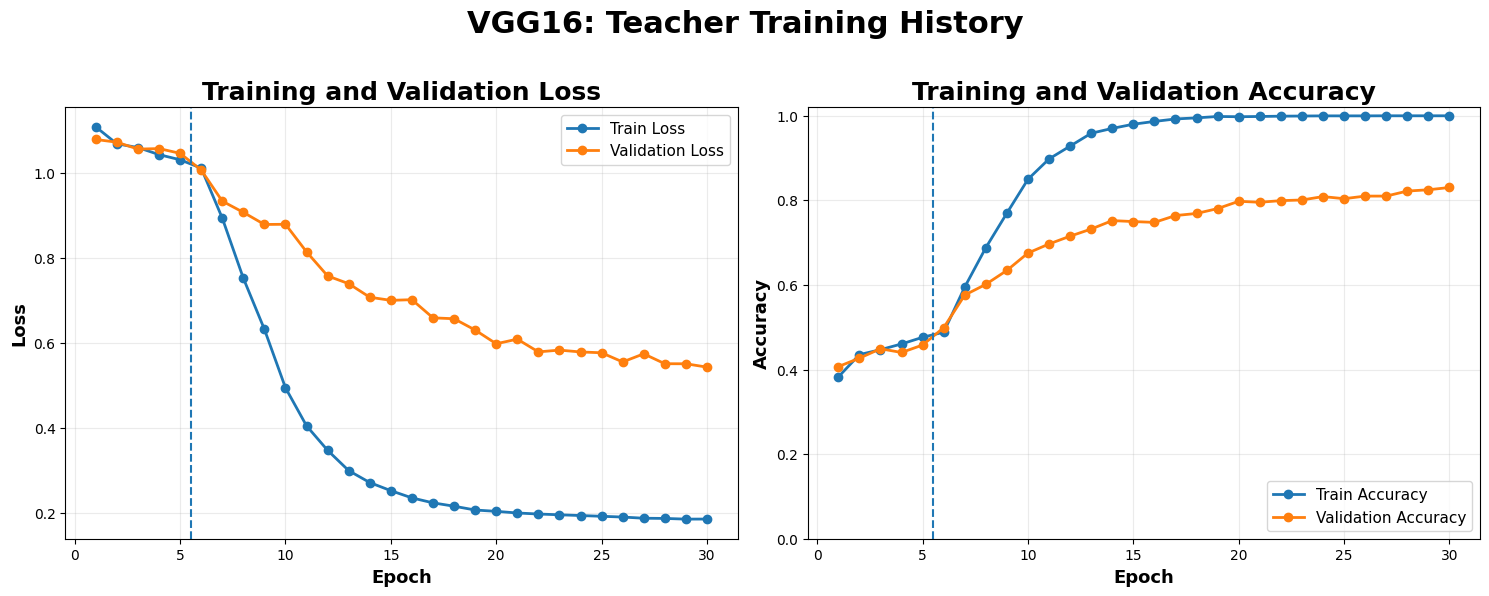


ResNet50: STAC Stage A - training the teacher on labeled_df only


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | teacher | head | epoch 01 | train loss 1.1211 | val loss 1.0911 | train acc 0.3589 | val acc 0.3832


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | teacher | fine_tune | epoch 29 | train loss 0.2442 | val loss 0.6137 | train acc 0.9836 | val acc 0.7948


Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | teacher | fine_tune | epoch 30 | train loss 0.2378 | val loss 0.6247 | train acc 0.9852 | val acc 0.7883


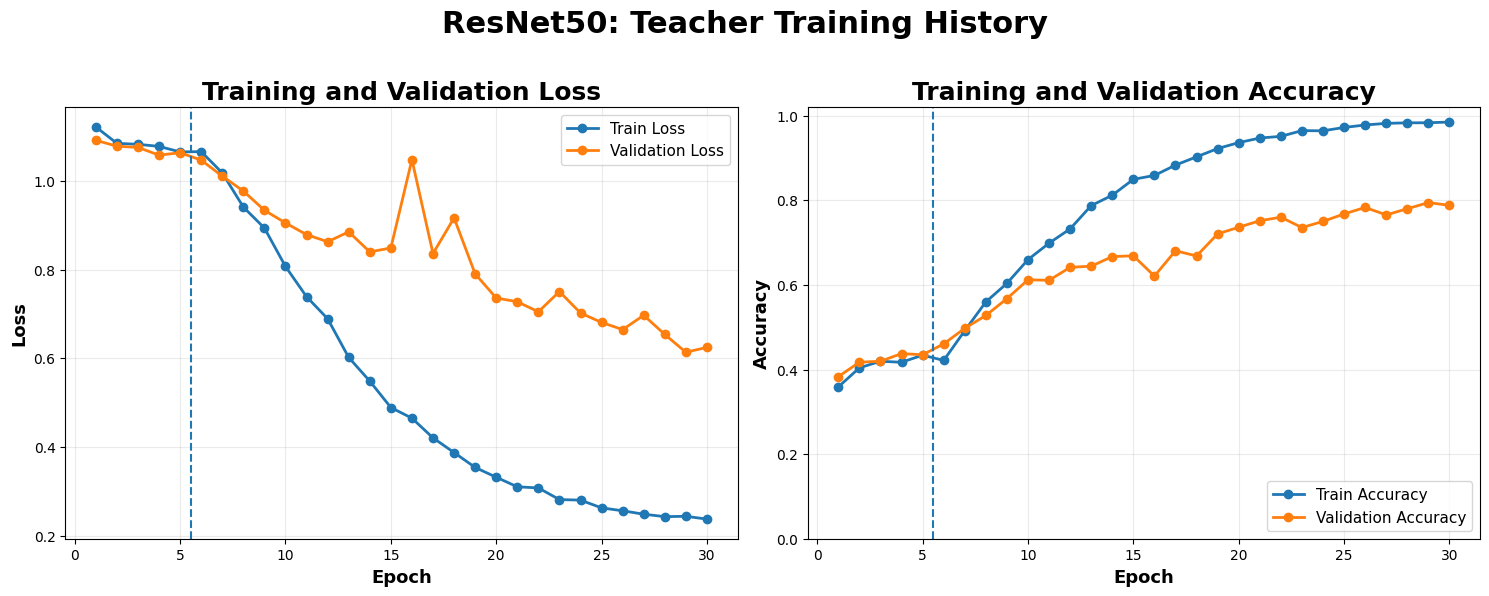


ConvNeXtSmall: STAC Stage A - training the teacher on labeled_df only


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | teacher | head | epoch 01 | train loss 1.2146 | val loss 1.0959 | train acc 0.3500 | val acc 0.3913


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | teacher | fine_tune | epoch 29 | train loss 0.2121 | val loss 0.6744 | train acc 0.9951 | val acc 0.7695


Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | teacher | fine_tune | epoch 30 | train loss 0.2064 | val loss 0.6832 | train acc 0.9963 | val acc 0.7683


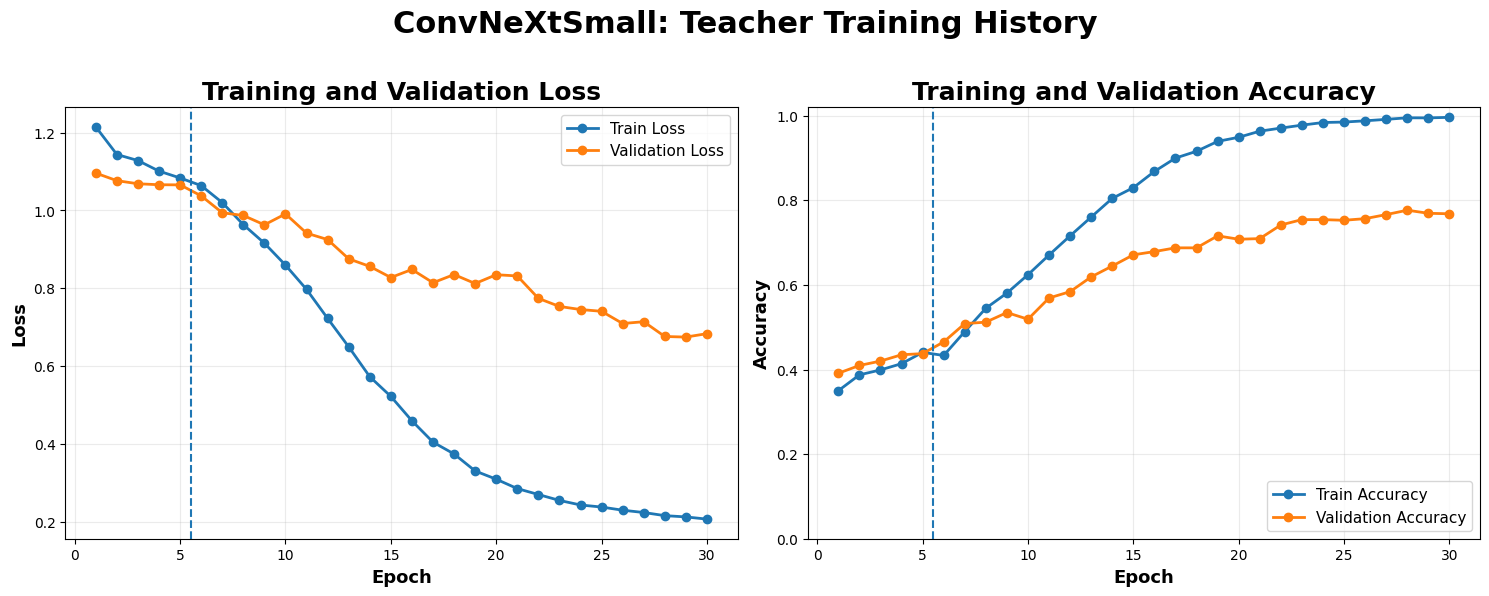

In [10]:
def train_teacher(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_stac_teacher_best.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_stac_teacher_history.csv'
    metadata_path = TABLE_DIR / f'{model_label.lower()}_stac_teacher_training.json'

    if RESUME_IF_AVAILABLE and checkpoint_path.exists():
        payload = load_checkpoint(checkpoint_path, DEVICE)
        if payload.get('experiment_id') == EXPERIMENT_ID:
            print(f'{model_label}: teacher already trained, reusing saved checkpoint.')
            return checkpoint_path

    model, timm_name, mean, std = build_model(model_label, pretrained=True)
    model = model.to(DEVICE)

    train_loader = make_labeled_train_loader(mean, std, LABELED_BATCH_SIZE)
    val_loader, test_loader = make_eval_loaders(mean, std)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    scaler = make_scaler()

    history = []
    best_score = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    global_epoch = 0
    training_start = time.perf_counter()

    stages = [('head', TEACHER_HEAD_EPOCHS), ('fine_tune', TEACHER_FINE_TUNE_EPOCHS)]

    for stage, stage_epochs in stages:
        if stage == 'fine_tune' and checkpoint_path.exists():
            checkpoint = load_checkpoint(checkpoint_path, DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])

        configure_stage(model, stage)
        optimizer = make_optimizer(model, stage)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-7,
        )
        patience_count = 0

        for _ in range(stage_epochs):
            global_epoch += 1

            train_loss, train_accuracy, train_f1 = run_epoch(
                model, train_loader, criterion, optimizer, scaler, stage,
            )
            val_loss, val_accuracy, val_f1 = run_epoch(model, val_loader, criterion)

            scheduler.step(val_f1)
            learning_rates = [group['lr'] for group in optimizer.param_groups]

            history.append({
                'epoch': global_epoch, 'stage': stage,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_accuracy': train_accuracy, 'val_accuracy': val_accuracy,
                'train_f1': train_f1, 'val_f1': val_f1,
                'learning_rate': max(learning_rates),
            })

            improved = (
                val_f1 > best_score + MIN_DELTA
                or (abs(val_f1 - best_score) <= MIN_DELTA and val_loss < best_val_loss)
            )

            if improved:
                best_score = val_f1
                best_val_loss = val_loss
                best_epoch = global_epoch
                patience_count = 0

                torch.save({
                    'experiment_id': EXPERIMENT_ID,
                    'model_state_dict': model.state_dict(),
                    'model_label': model_label,
                    'timm_name': timm_name,
                    'class_names': class_names,
                    'mean': mean,
                    'std': std,
                    'best_epoch': best_epoch,
                    'best_val_f1': float(best_score),
                    'best_val_loss': float(best_val_loss),
                }, checkpoint_path)
            else:
                patience_count += 1

            print(
                f'{model_label} | teacher | {stage} | epoch {global_epoch:02d} | '
                f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
                f'train acc {train_accuracy:.4f} | val acc {val_accuracy:.4f}'
            )

            if stage == 'fine_tune' and patience_count >= PATIENCE:
                print(f'Early stopping at epoch {global_epoch}.')
                break

    training_seconds = time.perf_counter() - training_start
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    metadata = {
        'experiment_id': EXPERIMENT_ID,
        'model': model_label,
        'timm_name': timm_name,
        'best_epoch': best_epoch,
        'best_val_f1': float(best_score),
        'best_val_loss': float(best_val_loss),
        'training_seconds': float(training_seconds),
        'labeled_images': int(len(labeled_df)),
    }
    metadata_path.write_text(json.dumps(metadata, indent=2))
    save_history_plot(history, model_label, 'Teacher Training History', 'teacher_history')

    model.to('cpu')
    del model, train_loader, val_loader, test_loader
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return checkpoint_path


for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'{model_label}: STAC Stage A - training the teacher on labeled_df only')
    print('=' * 88)
    train_teacher(model_label)


## Stage B — Pseudo-Labeling `unlabeled_df`

Each teacher labels every image in `unlabeled_df` once (weak augmentation).
Only predictions with confidence ≥ `CONFIDENCE_THRESHOLD` are written to the
per-model pseudo-label manifest used for student training. The (diagnostic
only) agreement with the true labels is also reported.


In [11]:
def generate_pseudo_labels(model_label):
    teacher_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_stac_teacher_best.pth'
    confident_manifest_path = TABLE_DIR / f'{model_label.lower()}_stac_confident_pseudo_labels.csv'
    all_manifest_path = TABLE_DIR / f'{model_label.lower()}_stac_all_pseudo_labels.csv'

    if not teacher_ckpt.exists():
        raise FileNotFoundError(f'No teacher checkpoint found for {model_label}. Train the teacher first.')

    if RESUME_IF_AVAILABLE and confident_manifest_path.exists():
        existing = pd.read_csv(confident_manifest_path)
        print(f'{model_label}: pseudo-label manifest already exists, reusing '
              f'({len(existing):,} confidently pseudo-labeled images).')
        return confident_manifest_path

    payload = load_checkpoint(teacher_ckpt, DEVICE)
    timm_name = payload['timm_name']
    mean = payload['mean']
    std = payload['std']

    model = TransferClassifier(timm_name, len(class_names), pretrained=False)
    model.load_state_dict(payload['model_state_dict'])
    model = model.to(DEVICE)
    model.eval()

    weak_transform, _ = make_transforms(mean, std)
    inference_loader = DataLoader(
        MRIFrameDataset(unlabeled_df, weak_transform),
        batch_size=PSEUDO_LABEL_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    all_paths, all_pseudo_labels, all_confidences, all_true_labels = [], [], [], []

    with torch.no_grad():
        for images, true_labels, paths in tqdm(inference_loader, desc=f'{model_label}: generating pseudo-labels'):
            images = images.to(DEVICE, non_blocking=True)
            with autocast_context(False):
                logits = model(images)
            probabilities = torch.softmax(logits.float(), dim=1)
            confidences, pseudo_labels = probabilities.max(dim=1)

            all_paths.extend(paths)
            all_pseudo_labels.extend(pseudo_labels.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())
            all_true_labels.extend(true_labels.numpy())

    manifest = pd.DataFrame({
        'path': all_paths,
        'pseudo_label': all_pseudo_labels,
        'confidence': all_confidences,
        'true_label_diagnostic_only': all_true_labels,
    })
    manifest.to_csv(all_manifest_path, index=False)

    threshold = CONFIDENCE_THRESHOLD
    confident_manifest = manifest[manifest['confidence'] >= threshold].reset_index(drop=True)

    while len(confident_manifest) < MIN_CONFIDENT_PSEUDO_LABELS and threshold > CONFIDENCE_THRESHOLD_FLOOR:
        threshold = round(threshold - 0.05, 2)
        confident_manifest = manifest[manifest['confidence'] >= threshold].reset_index(drop=True)

    if threshold != CONFIDENCE_THRESHOLD:
        print(f'{model_label}: confidence threshold auto-relaxed from {CONFIDENCE_THRESHOLD} to {threshold} '
              f'to reach at least {MIN_CONFIDENT_PSEUDO_LABELS} pseudo-labels.')
    if len(confident_manifest) == 0:
        print(f'{model_label}: WARNING - zero confident pseudo-labels even at the floor threshold '
              f'{CONFIDENCE_THRESHOLD_FLOOR}. The teacher is not calibrated enough yet; consider training '
              f'it longer (raise TEACHER_FINE_TUNE_EPOCHS) or raising LABELED_FRACTION.')

    confident_manifest[['path', 'pseudo_label', 'confidence']].to_csv(confident_manifest_path, index=False)

    retained_fraction = len(confident_manifest) / len(manifest) if len(manifest) else 0.0
    diagnostic_accuracy = (
        float((confident_manifest['pseudo_label'] == confident_manifest['true_label_diagnostic_only']).mean())
        if len(confident_manifest) else float('nan')
    )

    print(
        f'{model_label}: kept {len(confident_manifest):,} / {len(manifest):,} unlabeled images '
        f'({retained_fraction:.1%}) at confidence >= {CONFIDENCE_THRESHOLD}.'
    )
    print(
        f'{model_label}: pseudo-label accuracy vs. true labels '
        f'(diagnostic only, NOT used for training/model selection): {diagnostic_accuracy:.4f}'
    )

    if len(confident_manifest):
        class_distribution = (
            pd.Series([class_names[i] for i in confident_manifest['pseudo_label']])
            .value_counts()
            .reindex(class_names, fill_value=0)
        )
        display(class_distribution.to_frame('Confidently pseudo-labeled count'))

    model.to('cpu')
    del model, inference_loader
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return confident_manifest_path


for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'{model_label}: STAC Stage B - pseudo-labeling unlabeled_df with the teacher')
    print('=' * 88)
    generate_pseudo_labels(model_label)



VGG16: STAC Stage B - pseudo-labeling unlabeled_df with the teacher


VGG16: generating pseudo-labels:   0%|          | 0/58 [00:00<?, ?it/s]

VGG16: kept 1,942 / 3,650 unlabeled images (53.2%) at confidence >= 0.8.
VGG16: pseudo-label accuracy vs. true labels (diagnostic only, NOT used for training/model selection): 0.9614


,Confidently pseudo-labeled count
Herniated Disc,649
No Stenosis,681
Thecal Sac,612



ResNet50: STAC Stage B - pseudo-labeling unlabeled_df with the teacher


...

,Confidently pseudo-labeled count
Herniated Disc,856
No Stenosis,749
Thecal Sac,554



ConvNeXtSmall: STAC Stage B - pseudo-labeling unlabeled_df with the teacher


ConvNeXtSmall: generating pseudo-labels:   0%|          | 0/58 [00:00<?, ?it/s]

ConvNeXtSmall: kept 2,378 / 3,650 unlabeled images (65.2%) at confidence >= 0.8.
ConvNeXtSmall: pseudo-label accuracy vs. true labels (diagnostic only, NOT used for training/model selection): 0.8797


,Confidently pseudo-labeled count
Herniated Disc,653
No Stenosis,1021
Thecal Sac,704


## Stage C — Student Training (labeled_df + confident pseudo-labels)

The student is a **fresh** classifier (fresh ImageNet init unless
`STUDENT_WARM_START = True`), trained on the combined loss described above.
This is the final STAC model that gets evaluated on the test split.


In [12]:
def build_student_model(model_label, teacher_mean_std):
    mean, std = teacher_mean_std
    if STUDENT_WARM_START:
        teacher_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_stac_teacher_best.pth'
        payload = load_checkpoint(teacher_ckpt, DEVICE)
        timm_name = payload['timm_name']
        model = TransferClassifier(timm_name, len(class_names), pretrained=False)
        model.load_state_dict(payload['model_state_dict'])
        return model, timm_name
    else:
        model, timm_name, _, _ = build_model(model_label, pretrained=True)
        return model, timm_name


def train_student(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_stac_student_best.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_stac_student_history.csv'
    metadata_path = TABLE_DIR / f'{model_label.lower()}_stac_student_training.json'
    pseudo_manifest_path = TABLE_DIR / f'{model_label.lower()}_stac_confident_pseudo_labels.csv'
    teacher_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_stac_teacher_best.pth'

    teacher_payload = load_checkpoint(teacher_ckpt, DEVICE)
    mean = teacher_payload['mean']
    std = teacher_payload['std']

    model, timm_name = build_student_model(model_label, (mean, std))
    model = model.to(DEVICE)

    pseudo_df = pd.read_csv(pseudo_manifest_path)
    if pseudo_df.empty:
        raise RuntimeError(
            f'{model_label}: no confidently pseudo-labeled images available. '
            f'Consider lowering CONFIDENCE_THRESHOLD.'
        )

    labeled_loader = make_labeled_train_loader(mean, std, LABELED_BATCH_SIZE)
    strong_transform = make_strong_transform(mean, std)
    pseudo_generator = torch.Generator().manual_seed(SEED)
    pseudo_loader = DataLoader(
        PseudoLabeledDataset(pseudo_df, strong_transform),
        batch_size=min(UNLABELED_BATCH_SIZE, len(pseudo_df)),
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=pseudo_generator,
        drop_last=True,
    )
    val_loader, test_loader = make_eval_loaders(mean, std)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    scaler = make_scaler()

    history = []
    best_score = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    global_epoch = 0
    training_start = time.perf_counter()

    stages = [('head', STUDENT_HEAD_EPOCHS), ('fine_tune', STUDENT_FINE_TUNE_EPOCHS)]

    for stage, stage_epochs in stages:
        if stage == 'fine_tune' and checkpoint_path.exists():
            checkpoint = load_checkpoint(checkpoint_path, DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])

        configure_stage(model, stage)
        optimizer = make_optimizer(model, stage)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-7,
        )
        patience_count = 0

        for stage_epoch_index in range(stage_epochs):
            global_epoch += 1
            lambda_u = unlabeled_loss_weight(stage, stage_epoch_index)

            train_loss, train_accuracy, train_f1 = run_epoch_student_train(
                model, labeled_loader, pseudo_loader, criterion, optimizer, scaler, stage, lambda_u,
            )
            val_loss, val_accuracy, val_f1 = run_epoch(model, val_loader, criterion)

            scheduler.step(val_f1)
            learning_rates = [group['lr'] for group in optimizer.param_groups]

            history.append({
                'epoch': global_epoch, 'stage': stage,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_accuracy': train_accuracy, 'val_accuracy': val_accuracy,
                'train_f1': train_f1, 'val_f1': val_f1,
                'learning_rate': max(learning_rates),
            })

            improved = (
                val_f1 > best_score + MIN_DELTA
                or (abs(val_f1 - best_score) <= MIN_DELTA and val_loss < best_val_loss)
            )

            if improved:
                best_score = val_f1
                best_val_loss = val_loss
                best_epoch = global_epoch
                patience_count = 0

                torch.save({
                    'experiment_id': EXPERIMENT_ID,
                    'model_state_dict': model.state_dict(),
                    'model_label': model_label,
                    'timm_name': timm_name,
                    'class_names': class_names,
                    'mean': mean,
                    'std': std,
                    'best_epoch': best_epoch,
                    'best_val_f1': float(best_score),
                    'best_val_loss': float(best_val_loss),
                }, checkpoint_path)
            else:
                patience_count += 1

            print(
                f'{model_label} | student | {stage} | epoch {global_epoch:02d} | lambda_u {lambda_u:.2f} | '
                f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
                f'train acc {train_accuracy:.4f} | val acc {val_accuracy:.4f}'
            )

            if stage == 'fine_tune' and patience_count >= PATIENCE:
                print(f'Early stopping at epoch {global_epoch}.')
                break

    training_seconds = time.perf_counter() - training_start
    best_checkpoint = load_checkpoint(checkpoint_path, DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    metadata = {
        'experiment_id': EXPERIMENT_ID,
        'model': model_label,
        'timm_name': timm_name,
        'best_epoch': best_epoch,
        'best_val_f1': float(best_score),
        'best_val_loss': float(best_val_loss),
        'training_seconds': float(training_seconds),
        'labeled_images': int(len(labeled_df)),
        'confident_pseudo_labeled_images': int(len(pseudo_df)),
    }
    metadata_path.write_text(json.dumps(metadata, indent=2))
    save_history_plot(history, model_label, 'STAC Student Training History', 'student_history')

    return model, val_loader, test_loader, metadata


## Evaluation Utilities

In [13]:
def predict_classes(model, loader):
    model.eval()
    labels_all, predictions_all, paths_all = [], [], []
    start = time.perf_counter()

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, leave=False, desc='Predicting'):
            images = images.to(DEVICE, non_blocking=True)
            with autocast_context(False):
                logits = model(images)
            predictions = logits.argmax(dim=1).cpu().numpy()
            labels_all.append(labels.numpy())
            predictions_all.append(predictions)
            paths_all.extend(paths)

    elapsed = time.perf_counter() - start
    return np.concatenate(labels_all), np.concatenate(predictions_all), np.asarray(paths_all), elapsed


def calculate_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }


def plot_confusion_matrix(matrix, model_label):
    fig, axis = plt.subplots(figsize=(8.8, 7.5))
    image = axis.imshow(matrix, interpolation='nearest', cmap='Blues')
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    colorbar.ax.tick_params(labelsize=12)

    threshold = matrix.max() / 2 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = int(matrix[row, column])
            axis.text(
                column, row, str(value), ha='center', va='center',
                fontsize=21, fontweight='bold',
                color='white' if value > threshold else 'black',
            )

    axis.set_xticks(np.arange(len(class_names)))
    axis.set_yticks(np.arange(len(class_names)))
    axis.set_xticklabels(class_names, rotation=18, ha='right', fontsize=14, fontweight='bold')
    axis.set_yticklabels(class_names, fontsize=14, fontweight='bold')
    axis.set_xlabel('Predicted Label', fontsize=17, fontweight='bold', labelpad=12)
    axis.set_ylabel('True Label', fontsize=17, fontweight='bold', labelpad=12)
    axis.set_title(f'STAC-{model_label} Confusion Matrix', fontsize=23, fontweight='bold', pad=16)

    fig.tight_layout()
    save_figure(fig, f'confusion_matrix_stac_{model_label.lower()}')
    plt.show()


def save_evaluation(model_label, model, test_loader, metadata):
    y_true, y_pred, paths, inference_seconds = predict_classes(model, test_loader)

    metrics = calculate_metrics(y_true, y_pred)
    metrics.update({
        'experiment_id': EXPERIMENT_ID,
        'model': f'STAC-{model_label}',
        'input_size': INPUT_SIZE,
        'best_epoch': metadata['best_epoch'],
        'training_seconds': metadata['training_seconds'],
        'inference_ms_per_image': float(inference_seconds * 1000 / len(y_true)),
        'labeled_images': metadata['labeled_images'],
        'confident_pseudo_labeled_images': metadata['confident_pseudo_labeled_images'],
    })

    report = classification_report(
        y_true, y_pred, labels=np.arange(len(class_names)),
        target_names=class_names, output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(TABLE_DIR / f'stac_{model_label.lower()}_classification_report.csv')

    pd.DataFrame({
        'path': paths,
        'true_label': [class_names[index] for index in y_true],
        'predicted_label': [class_names[index] for index in y_pred],
    }).to_csv(TABLE_DIR / f'stac_{model_label.lower()}_test_predictions.csv', index=False)

    (TABLE_DIR / f'stac_{model_label.lower()}_metrics.json').write_text(json.dumps(metrics, indent=2))

    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    plot_confusion_matrix(matrix, model_label)

    return metrics


def completed_metrics(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_stac_student_best.pth'
    metrics_path = TABLE_DIR / f'stac_{model_label.lower()}_metrics.json'

    if not RESUME_IF_AVAILABLE:
        return None

    if checkpoint_path.exists() and metrics_path.exists():
        metrics = json.loads(metrics_path.read_text())
        if metrics.get('experiment_id') == EXPERIMENT_ID:
            return metrics

    return None


## Train and Evaluate STAC-VGG16, STAC-ResNet50, STAC-ConvNeXt Small


STAC-VGG16: Stage C - training the student


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | student | head | epoch 01 | lambda_u 0.00 | train loss 1.1128 | val loss 1.0771 | train acc 0.3721 | val acc 0.4173


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | student | fine_tune | epoch 29 | lambda_u 1.00 | train loss 0.4169 | val loss 0.5387 | train acc 1.0000 | val acc 0.8312


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | student | fine_tune | epoch 30 | lambda_u 1.00 | train loss 0.4102 | val loss 0.5374 | train acc 0.9996 | val acc 0.8255


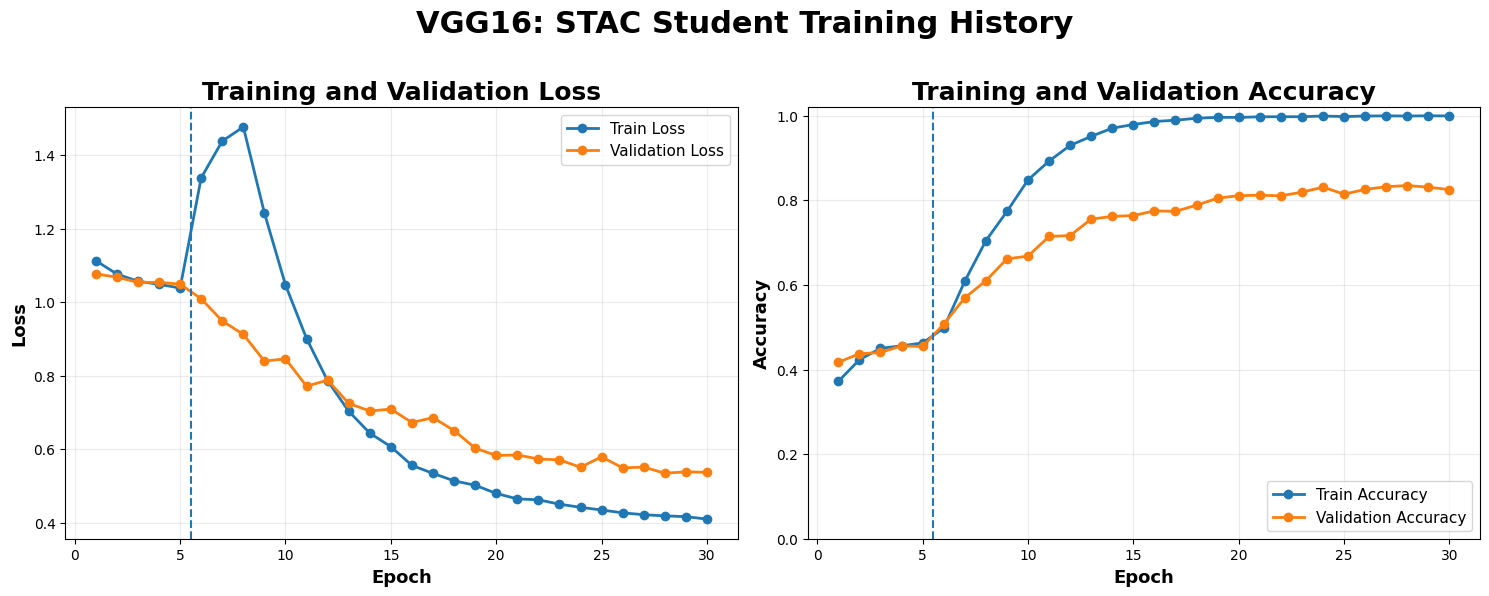

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

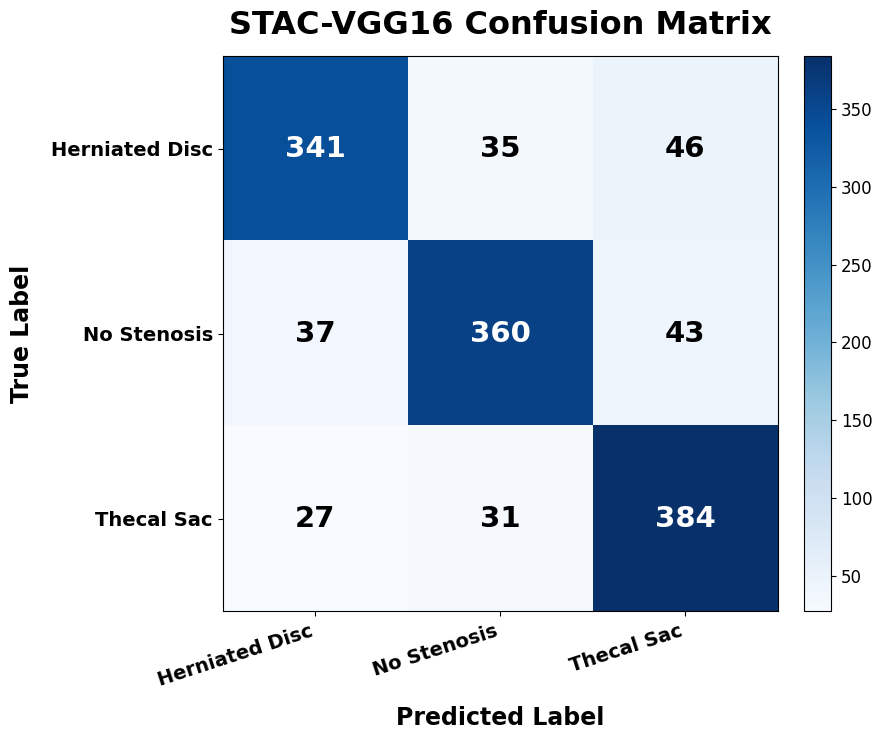

,Accuracy,Precision,Recall,F1 Score
Model,,,,
STAC-VGG16,0.832055,0.832962,0.831672,0.831807



STAC-ResNet50: Stage C - training the student


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | student | head | epoch 01 | lambda_u 0.00 | train loss 1.1140 | val loss 1.0916 | train acc 0.3640 | val acc 0.3771


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | student | fine_tune | epoch 29 | lambda_u 1.00 | train loss 0.5710 | val loss 0.6656 | train acc 0.9783 | val acc 0.7879


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | student | fine_tune | epoch 30 | lambda_u 1.00 | train loss 0.5470 | val loss 0.6703 | train acc 0.9837 | val acc 0.7894


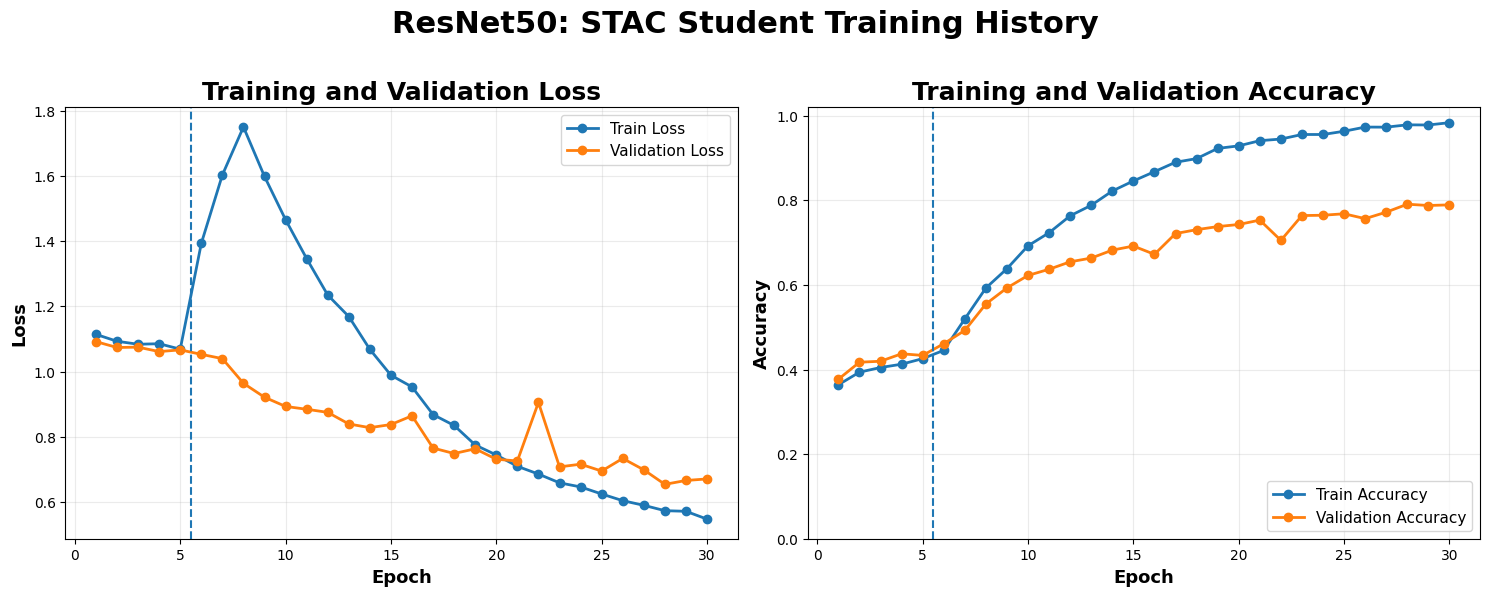

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

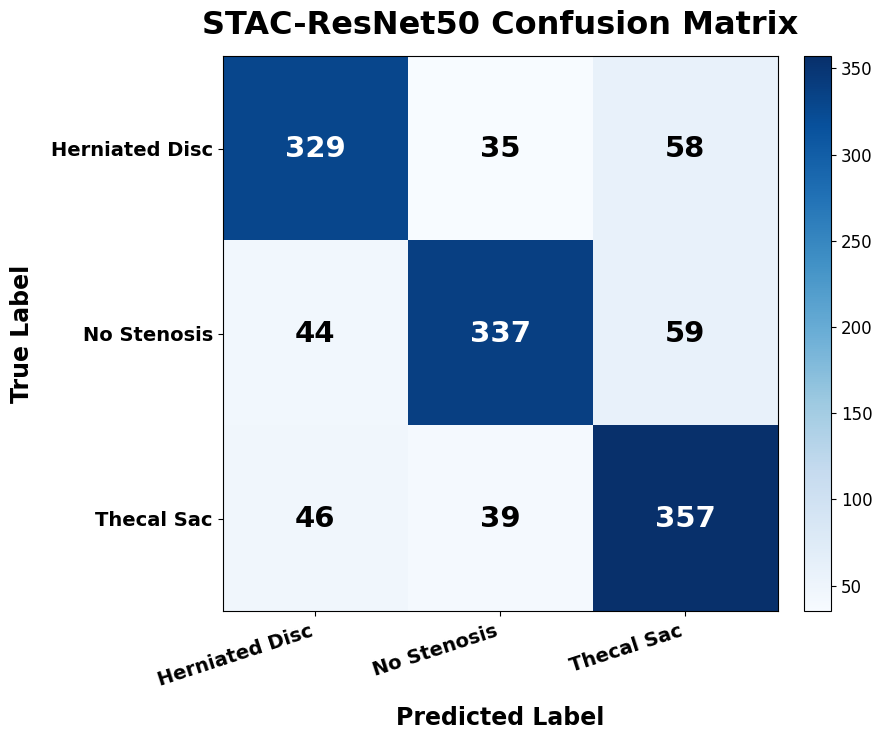

,Accuracy,Precision,Recall,F1 Score
Model,,,,
STAC-ResNet50,0.784509,0.786106,0.784407,0.784629



STAC-ConvNeXtSmall: Stage C - training the student


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | student | head | epoch 01 | lambda_u 0.00 | train loss 1.1997 | val loss 1.0948 | train acc 0.3697 | val acc 0.3886


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | student | fine_tune | epoch 29 | lambda_u 1.00 | train loss 0.4424 | val loss 0.7273 | train acc 0.9925 | val acc 0.7725


Training (student):   0%|          | 0/171 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | student | fine_tune | epoch 30 | lambda_u 1.00 | train loss 0.4384 | val loss 0.7214 | train acc 0.9934 | val acc 0.7802


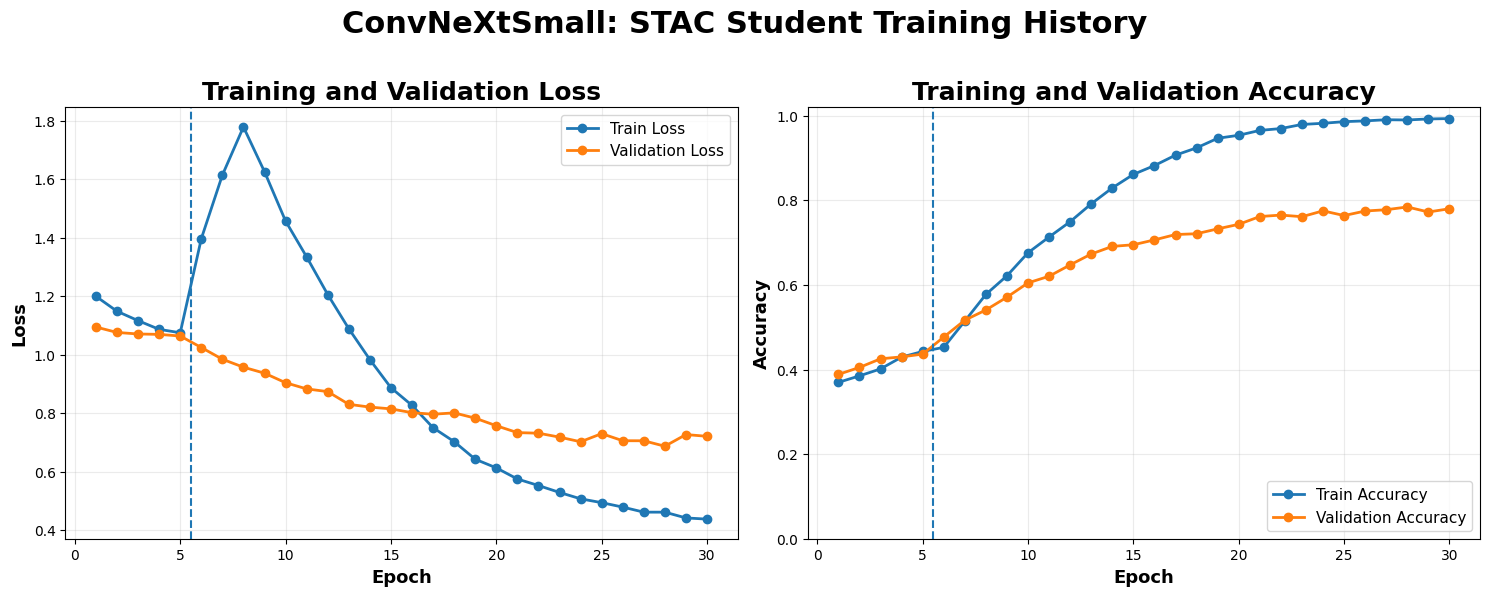

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

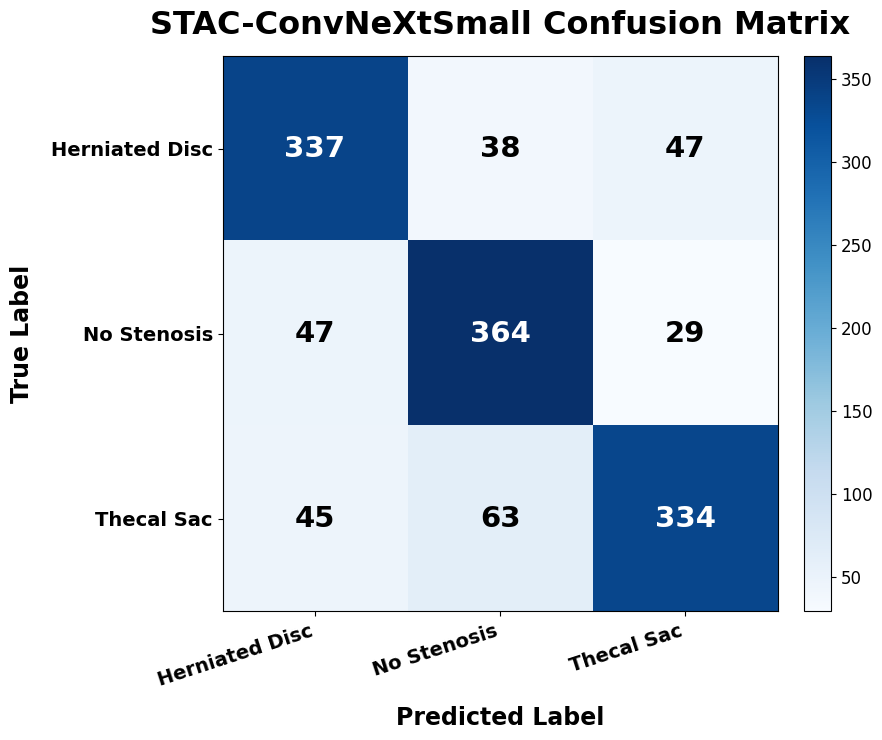

,Accuracy,Precision,Recall,F1 Score
Model,,,,
STAC-ConvNeXtSmall,0.793712,0.794326,0.793836,0.793489


In [14]:
all_metrics = []

for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'STAC-{model_label}: Stage C - training the student')
    print('=' * 88)

    saved = completed_metrics(model_label)

    if saved is not None:
        print('Loaded completed result for the current experiment configuration.')
        all_metrics.append(saved)
        continue

    model, val_loader, test_loader, metadata = train_student(model_label)
    metrics = save_evaluation(model_label, model, test_loader, metadata)

    all_metrics.append(metrics)

    display(pd.DataFrame([{
        'Model': f'STAC-{model_label}',
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1_score'],
    }]).set_index('Model'))

    model.to('cpu')
    del model, val_loader, test_loader
    gc.collect()

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


## Model Comparison

In [15]:
comparison = (
    pd.DataFrame(all_metrics)
    .sort_values('f1_score', ascending=False)
    .reset_index(drop=True)
)

comparison_table = comparison[['model', 'accuracy', 'precision', 'recall', 'f1_score']].copy()
comparison_table.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

comparison_table.to_csv(TABLE_DIR / 'stac_model_comparison.csv', index=False)
(TABLE_DIR / 'stac_model_comparison.tex').write_text(
    comparison_table.to_latex(index=False, float_format='%.4f')
)

display(comparison_table)


,Model,Accuracy,Precision,Recall,F1 Score
0,STAC-VGG16,0.832055,0.832962,0.831672,0.831807
1,STAC-ConvNeXtSmall,0.793712,0.794326,0.793836,0.793489
2,STAC-ResNet50,0.784509,0.786106,0.784407,0.784629


## Export Paper Assets

In [16]:
run_summary = {
    'dataset': 'Lumbar Spinal MRI Dataset',
    'archive': str(ARCHIVE_PATH),
    'classes': class_names,
    'original_images': int(len(raw_df)),
    'retained_unique_images': int(len(cleaned_df)),
    'training_images': int(len(train_df)),
    'validation_images': int(len(val_df)),
    'test_images': int(len(test_df)),
    'labeled_images': int(len(labeled_df)),
    'unlabeled_images': int(len(unlabeled_df)),
    'labeled_fraction': LABELED_FRACTION,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'unlabeled_loss_weight': UNLABELED_LOSS_WEIGHT,
    'student_warm_start': STUDENT_WARM_START,
    'split': {'train': TRAIN_RATIO, 'validation': VAL_RATIO, 'test': TEST_RATIO},
    'input_size': INPUT_SIZE,
    'method': METHOD_NAME,
    'teacher_head_epochs': TEACHER_HEAD_EPOCHS,
    'teacher_fine_tune_epochs': TEACHER_FINE_TUNE_EPOCHS,
    'student_head_epochs': STUDENT_HEAD_EPOCHS,
    'student_fine_tune_epochs': STUDENT_FINE_TUNE_EPOCHS,
    'seed': SEED,
    'models': MODEL_SPECS,
    'preprocessing': [
        'foreground-aware crop',
        'robust 1st-99th percentile intensity normalization',
        'square padding',
        'three-channel conversion',
        '224x224 bicubic resizing',
        'weak augmentation for labeled_df and pseudo-label generation',
        'strong augmentation (affine/color/blur/solarize/erasing) for confident pseudo-labeled training',
        'pretrained-model normalization',
    ],
    'labeled_unlabeled_protocol': (
        f'{LABELED_FRACTION:.0%} of the training split is treated as labeled (stratified); '
        'the remaining training-split images have labels hidden and are only used through '
        'confidence-filtered pseudo-labels generated by the teacher. Validation/test remain fully '
        'labeled and untouched until early stopping / final evaluation respectively.'
    ),
    'patient_level_split_available': False,
}

(OUTPUT_DIR / 'run_summary.json').write_text(json.dumps(run_summary, indent=2))

readme = '\n'.join([
    'Lumbar Spinal MRI Classification — STAC Semi-Supervised Study',
    '',
    f'Original images: {len(raw_df):,}',
    f'Unique retained images: {len(cleaned_df):,}',
    f'Training images: {len(train_df):,}',
    f'  of which labeled (used directly): {len(labeled_df):,} ({LABELED_FRACTION:.0%})',
    f'  of which unlabeled (labels hidden, pseudo-labeled): {len(unlabeled_df):,}',
    f'Validation images: {len(val_df):,}',
    f'Test images: {len(test_df):,}',
    f"Classes: {', '.join(class_names)}",
    f"Models: {', '.join('STAC-' + m for m in MODELS_TO_RUN)}",
    f'Input size: {INPUT_SIZE} x {INPUT_SIZE}',
    f'Confidence threshold for pseudo-labels: {CONFIDENCE_THRESHOLD}',
    f'Unlabeled loss weight (lambda_u): {UNLABELED_LOSS_WEIGHT}',
    f'Student warm-started from teacher: {STUDENT_WARM_START}',
    '',
    'The dataset does not expose patient identifiers. The requested split is image-level. '
    'Exact duplicate images are removed before splitting. STAC uses an offline two-stage '
    'protocol: a teacher trained on the labeled subset produces confidence-filtered pseudo-labels '
    'once, and a fresh student is trained on labeled + pseudo-labeled data.',
])

(OUTPUT_DIR / 'README.txt').write_text(readme)

paper_zip = Path('/kaggle/working/lumbar_spinal_mri_stac_paper_assets.zip')

with zipfile.ZipFile(paper_zip, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for folder in [FIGURE_DIR, TABLE_DIR]:
        for path in folder.rglob('*'):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUT_DIR))

    archive.write(OUTPUT_DIR / 'README.txt', 'README.txt')
    archive.write(OUTPUT_DIR / 'run_summary.json', 'run_summary.json')

print(f'Figures: {FIGURE_DIR}')
print(f'Tables: {TABLE_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')
print(f'Paper assets ZIP: {paper_zip}')


Figures: /kaggle/working/lumbar_mri_stac_224_v2/paper_figures
Tables: /kaggle/working/lumbar_mri_stac_224_v2/tables
Checkpoints: /kaggle/working/lumbar_mri_stac_224_v2/checkpoints
Paper assets ZIP: /kaggle/working/lumbar_spinal_mri_stac_paper_assets.zip
